<a href="https://colab.research.google.com/github/shoxruxmamitov/kichik-loiha/blob/main/advanced_sales_dataset_xlsx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
df = pd.read_excel('advanced_sales_dataset.xlsx', index_col=0)
df

,Date,Region,City,Product,Category,Quantity,Unit_Price,Discount,Revenue,Cost,Profit
Order_ID,,,,,,,,,,,
1001,2023-02-03,Namangan,CityC,Laptop,Tech,5,1200,0.15,5100.0,4500,600.0
1002,2023-02-26,Fergana,CityB,Table,Furniture,1,300,0.05,285.0,200,85.0
1003,2023-01-16,Namangan,CityD,Headphone,Tech,1,100,0.15,85.0,60,25.0
1004,2023-02-19,Samarkand,CityC,Chair,Furniture,10,150,0.10,1350.0,900,450.0
1005,2023-03-26,Namangan,CityB,Phone,Tech,7,800,0.05,5320.0,4200,1120.0
...,...,...,...,...,...,...,...,...,...,...,...
1196,2023-01-25,Tashkent,CityA,Table,Furniture,2,300,0.10,540.0,400,140.0
1197,2023-01-31,Fergana,CityB,Phone,Tech,2,800,0.15,1360.0,1200,160.0
1198,2023-02-17,Tashkent,CityE,Laptop,Tech,1,1200,0.00,1200.0,900,300.0


In [ ]:
df.info() #malumotlarni chiqarib olamiz

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1001 to 1200
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        200 non-null    object 
 1   Region      200 non-null    object 
 2   City        200 non-null    object 
 3   Product     200 non-null    object 
 4   Category    200 non-null    object 
 5   Quantity    200 non-null    int64  
 6   Unit_Price  200 non-null    int64  
 7   Discount    200 non-null    float64
 8   Revenue     200 non-null    float64
 9   Cost        200 non-null    int64  
 10  Profit      200 non-null    float64
dtypes: float64(3), int64(3), object(5)
memory usage: 18.8+ KB


In [ ]:
df.columns

Index(['Date', 'Region', 'City', 'Product', 'Category', 'Quantity',
       'Unit_Price', 'Discount', 'Revenue', 'Cost', 'Profit'],
      dtype='object')

In [ ]:
df.describe() # umumi trendni tez tushunish uchun

,Quantity,Unit_Price,Discount,Revenue,Cost,Profit
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,5.485000,487.000000,0.080250,2424.912500,1858.500000,566.412500
std,2.933051,334.537857,0.057349,2122.922253,1733.116039,457.726149
min,1.000000,100.000000,0.000000,85.000000,60.000000,25.000000
25%,3.000000,150.000000,0.050000,680.000000,472.500000,185.625000
50%,5.000000,400.000000,0.100000,2040.000000,1500.000000,461.250000
75%,8.000000,700.000000,0.150000,3600.000000,2725.000000,806.250000
max,10.000000,1200.000000,0.150000,12000.000000,9000.000000,3000.000000


In [ ]:
df.isnull().sum() # NUN qimatlarni tekshirib oldik

,0
Date,0
Region,0
City,0
Product,0
Category,0
Quantity,0
Unit_Price,0
Discount,0
Revenue,0
Cost,0


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df # date ustunini datetime korinishiga keltirib oldik

,Date,Region,City,Product,Category,Quantity,Unit_Price,Discount,Revenue,Cost,Profit
Order_ID,,,,,,,,,,,
1001,2023-02-03,Namangan,CityC,Laptop,Tech,5,1200,0.15,5100.0,4500,600.0
1002,2023-02-26,Fergana,CityB,Table,Furniture,1,300,0.05,285.0,200,85.0
1003,2023-01-16,Namangan,CityD,Headphone,Tech,1,100,0.15,85.0,60,25.0
1004,2023-02-19,Samarkand,CityC,Chair,Furniture,10,150,0.10,1350.0,900,450.0
1005,2023-03-26,Namangan,CityB,Phone,Tech,7,800,0.05,5320.0,4200,1120.0
...,...,...,...,...,...,...,...,...,...,...,...
1196,2023-01-25,Tashkent,CityA,Table,Furniture,2,300,0.10,540.0,400,140.0
1197,2023-01-31,Fergana,CityB,Phone,Tech,2,800,0.15,1360.0,1200,160.0
1198,2023-02-17,Tashkent,CityE,Laptop,Tech,1,1200,0.00,1200.0,900,300.0


In [ ]:
df[df['Profit'] < 0] # manfi bolgan sonlarni aniqlab olish uchun ishlatdik bizda manfi son mavjud emas ekan

,Date,Region,City,Product,Category,Quantity,Unit_Price,Discount,Revenue,Cost,Profit
Order_ID,,,,,,,,,,,


In [ ]:
top_products = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False).head(10)
top_products # laptop eng kop sotilgan

,Revenue
Product,
Laptop,112500.0
Phone,81280.0
Sofa,78925.0
Tablet,71175.0
Monitor,64700.0
Table,46395.0
Chair,17242.5
Headphone,12765.0


In [ ]:
loss_products = df.groupby('Product')['Profit'].sum().sort_values()
loss_products # eng zarar productlar birinchi orinda Headphone

,Profit
Product,
Headphone,4605.0
Chair,5902.5
Table,12995.0
Phone,14080.0
Tablet,15875.0
Sofa,17925.0
Laptop,20700.0
Monitor,21200.0


In [ ]:
region_analiz = df.groupby('Region')[['Revenue', 'Profit']].sum().sort_values(by='Profit', ascending=True)
region_analiz  # qaysi viloyat yaxshi ishlayokanini aniqlab oldik

,Revenue,Profit
Region,,
Namangan,92620.0,19720.0
Tashkent,90277.5,19807.5
Samarkand,90360.0,21090.0
Fergana,97825.0,23745.0
Bukhara,113900.0,28920.0


In [ ]:
category_analiz = df.groupby('Category')[['Revenue', 'Profit']].sum()
category_analiz # tech va furniture boicha umumi natija

,Revenue,Profit
Category,,
Furniture,142562.5,36822.5
Tech,342420.0,76460.0


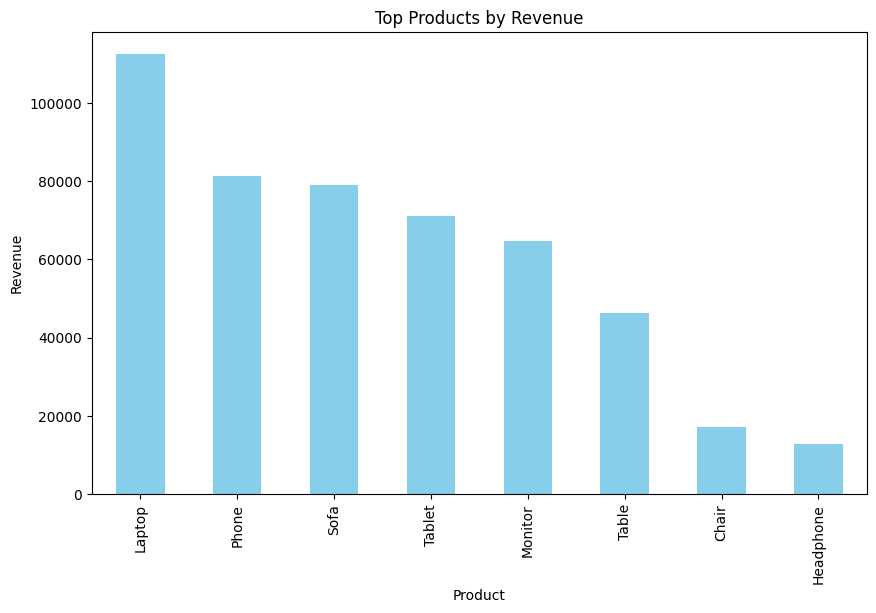

In [ ]:
plt.figure(figsize=(10, 6))
top_products.plot(kind='bar', color='skyblue')
plt.title('Top Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.show()

<Figure size 1000x600 with 0 Axes>

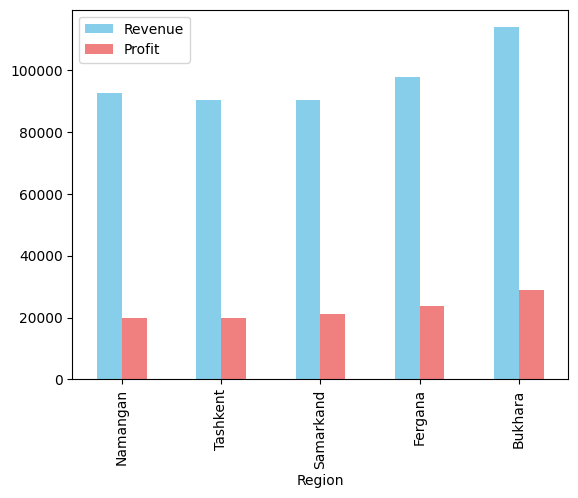

In [ ]:
plt.figure(figsize=(10, 6))
region_analiz.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.show()

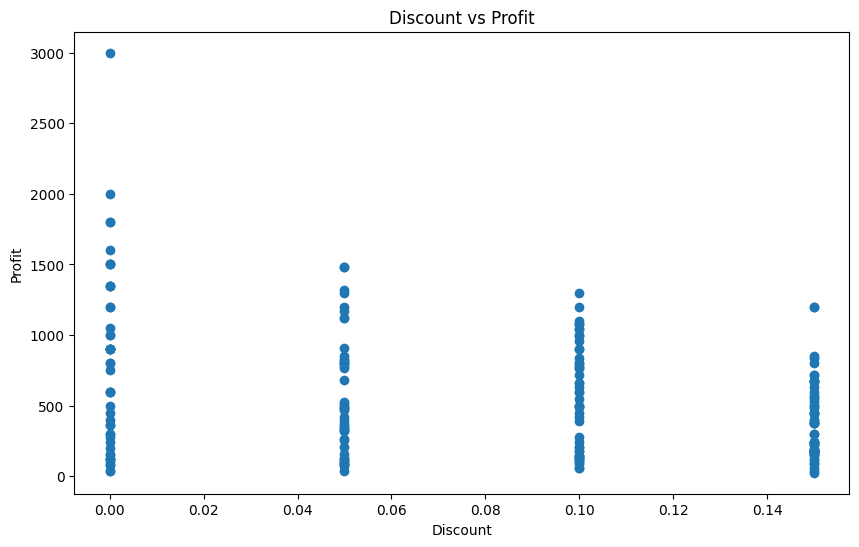

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Discount'], df['Profit'])
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

In [ ]:
df.head()

,Date,Region,City,Product,Category,Quantity,Unit_Price,Discount,Revenue,Cost,Profit
Order_ID,,,,,,,,,,,
1001,2023-02-03,Namangan,CityC,Laptop,Tech,5,1200,0.15,5100.0,4500,600.0
1002,2023-02-26,Fergana,CityB,Table,Furniture,1,300,0.05,285.0,200,85.0
1003,2023-01-16,Namangan,CityD,Headphone,Tech,1,100,0.15,85.0,60,25.0
1004,2023-02-19,Samarkand,CityC,Chair,Furniture,10,150,0.10,1350.0,900,450.0
1005,2023-03-26,Namangan,CityB,Phone,Tech,7,800,0.05,5320.0,4200,1120.0


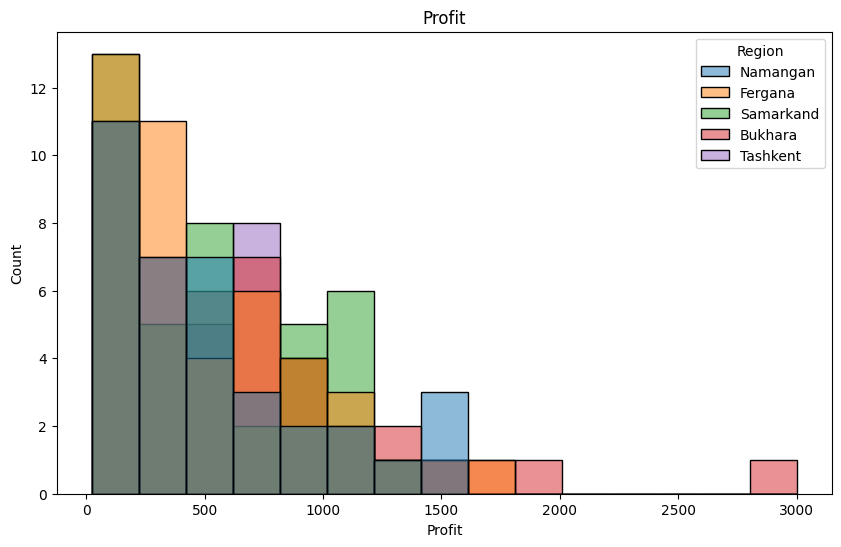

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(x='Profit', hue='Region', data=df)
plt.title('Profit')
plt.show()

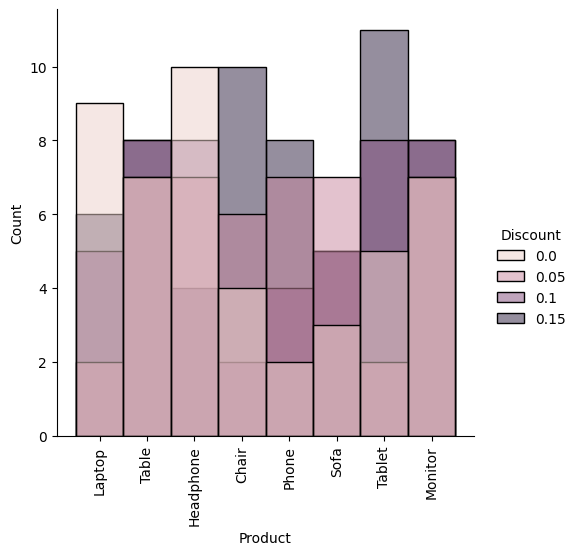

In [ ]:
sns.displot(data=df, x='Product', y='Discount')
plt.show()